In [1]:
import subprocess
subprocess.run(['pip','install','scikit-learn'])

CompletedProcess(args=['pip', 'install', 'scikit-learn'], returncode=0)

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("titanic_cleaned.csv")
print(df.columns)
print(df.head())

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone'],
      dtype='str')
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male  embark_town alive  alone  
0    man        True  Southampton    no  False  
1  woman       False    Cherbourg   yes  False  
2  woman       False  Southampton   yes   True  
3  woman       False  Southampton   yes  False  
4    man        True  Southampton    no   True  


In [4]:
print (df.columns.tolist())

['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']


In [5]:
df['sex'] = df['sex'].map({'male': 0, 'female': 1})

X = df[['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']]
y = df['survived']

X = X.fillna(X.mean())
print("Data ready!")
print(X.head())

Data ready!
   pclass  sex   age  sibsp  parch     fare
0       3    0  22.0      1      0   7.2500
1       1    1  38.0      1      0  71.2833
2       3    1  26.0      0      0   7.9250
3       1    1  35.0      1      0  53.1000
4       3    0  35.0      0      0   8.0500


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [7]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 80.26%


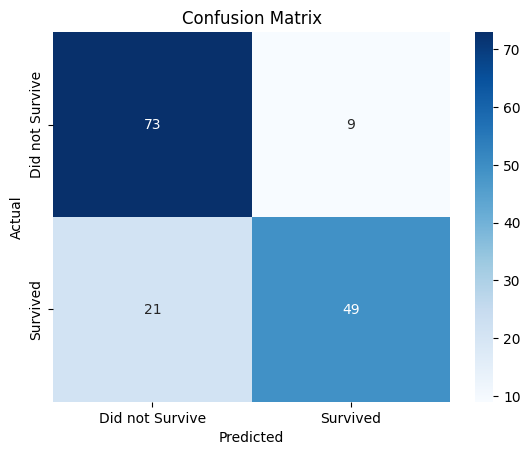

In [8]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Did not Survive', 'Survived'],
            yticklabels=['Did not Survive', 'Survived'])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.savefig("confusion_matrix.png")
plt.show()

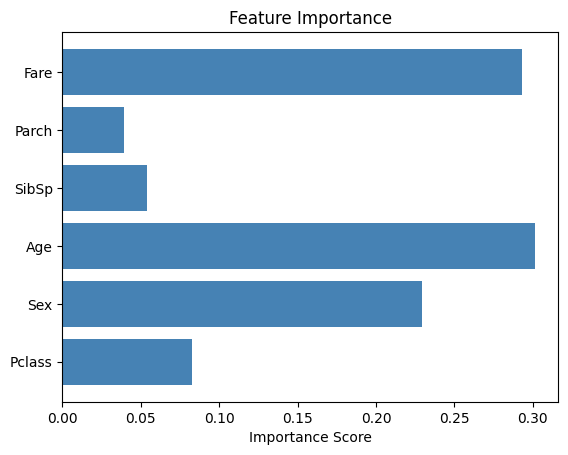

In [9]:
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
importance = model.feature_importances_

plt.barh(features, importance, color='steelblue')
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.savefig("feature_importance.png")
plt.show()

In [10]:
results = X_test.copy()
results['Actual'] = y_test.values
results['Predicted'] = y_pred
results.to_csv("predictions.csv", index=False)
print("All files saved!")

All files saved!


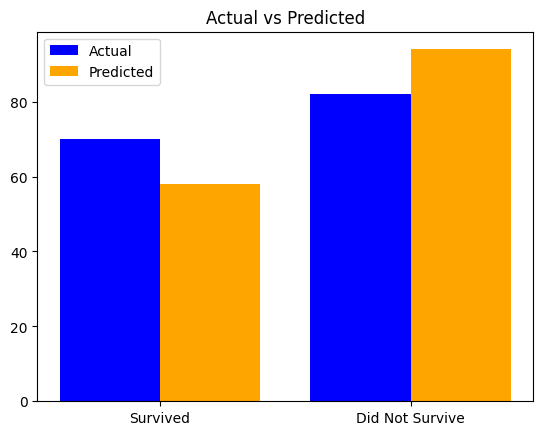

Graph 3 saved!


In [11]:
# Graph 3: Actual vs Predicted comparison
categories = ['Survived', 'Did Not Survive']
actual_counts = [sum(y_test == 1), sum(y_test == 0)]
predicted_counts = [sum(y_pred == 1), sum(y_pred == 0)]

x = range(len(categories))
plt.bar(x, actual_counts, width=0.4, 
        label='Actual', color='blue', align='center')
plt.bar([i+0.4 for i in x], predicted_counts, width=0.4,
        label='Predicted', color='orange', align='center')
plt.xticks([i+0.2 for i in x], categories)
plt.title("Actual vs Predicted")
plt.legend()
plt.savefig("actual_vs_predicted.png")
plt.show()
print("Graph 3 saved!")

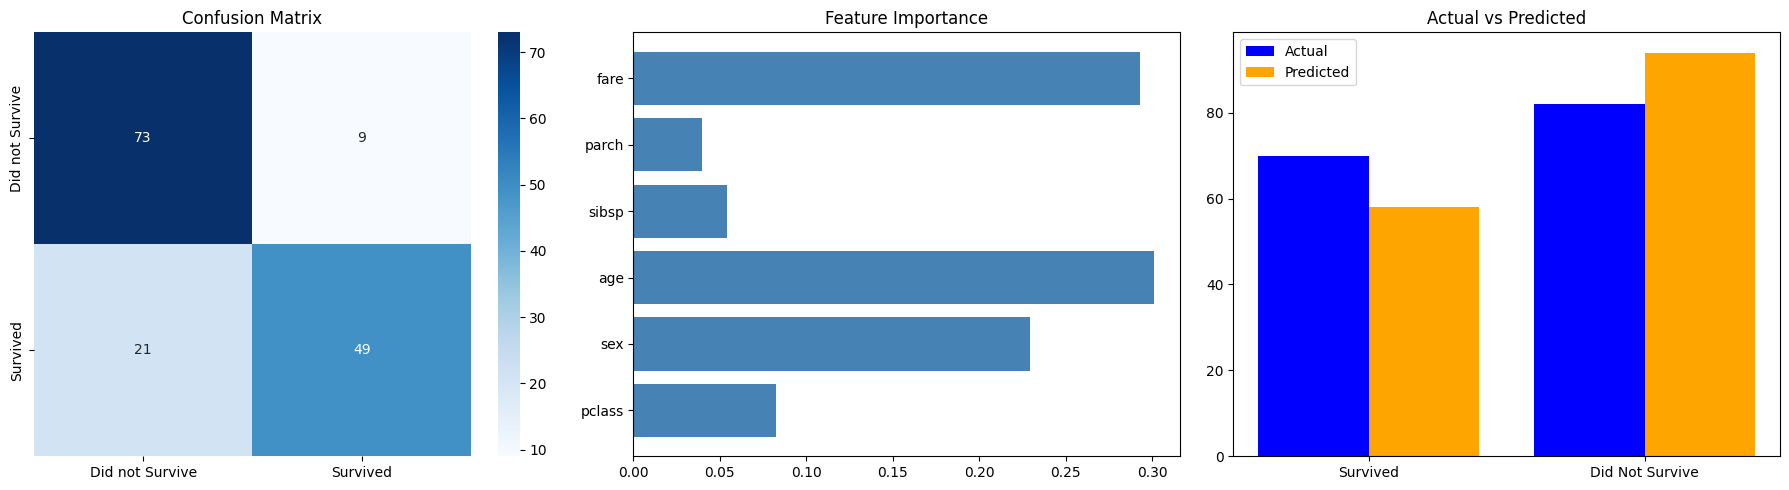

Full dashboard saved!


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Graph 1 - Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Did not Survive', 'Survived'],
            yticklabels=['Did not Survive', 'Survived'],
            ax=axes[0])
axes[0].set_title("Confusion Matrix")

# Graph 2 - Feature Importance
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']
axes[1].barh(features, model.feature_importances_, color='steelblue')
axes[1].set_title("Feature Importance")

# Graph 3 - Actual vs Predicted
axes[2].bar(x, actual_counts, width=0.4,
            label='Actual', color='blue', align='center')
axes[2].bar([i+0.4 for i in x], predicted_counts, width=0.4,
            label='Predicted', color='orange', align='center')
axes[2].set_xticks([i+0.2 for i in x])
axes[2].set_xticklabels(categories)
axes[2].set_title("Actual vs Predicted")
axes[2].legend()

plt.tight_layout()
plt.savefig("dashboard.png")
plt.show()
print("Full dashboard saved!")

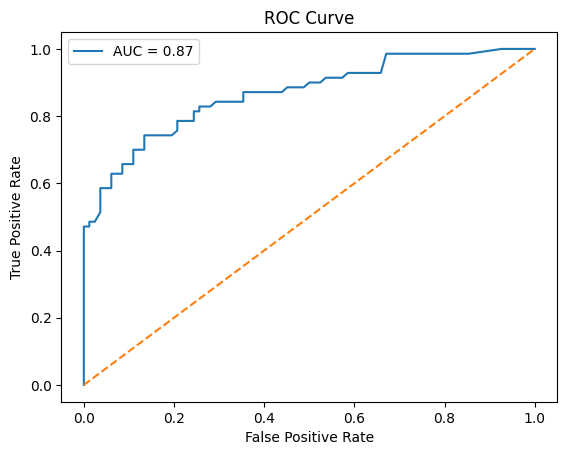

ROC Curve saved!


In [13]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.savefig("roc_curve.png")
plt.show()

print("ROC Curve saved!")

In [14]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.89      0.83        82
           1       0.84      0.70      0.77        70

    accuracy                           0.80       152
   macro avg       0.81      0.80      0.80       152
weighted avg       0.81      0.80      0.80       152



In [15]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy * 100)

Decision Tree Accuracy: 70.39473684210526
